In [ ]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Find all .benchmarks directories
benchmarks_dirs = list(Path('.').glob('**/.benchmarks'))
print(f"Found .benchmarks directories: {str(benchmarks_dirs)}")

# Find all JSON files in all .benchmarks subdirectories
json_files = []
for bench_dir in benchmarks_dirs:
    json_files.extend(bench_dir.glob('**/*.json'))

# Sort by modification time (latest first)
json_files.sort(key=lambda x: x.stat().st_mtime, reverse=True)

if json_files:
    latest_file = json_files[0]
    print(f"Latest benchmark file: {latest_file}")

    # Read the JSON file
    with open(latest_file, 'r') as f:
        benchmark_data = json.load(f)
else:
    print("No benchmark files found!")
    raise ValueError("No benchmark data loaded!")

Found .benchmarks directories: [PosixPath('.benchmarks')]
Latest benchmark file: .benchmarks/Linux-CPython-3.13-64bit/0002_f77e55752b6ae0438c2d302ebfae91172617d270_20260304_100844_uncommited-changes.json


In [ ]:
# Extract benchmark data and create DataFrame

benchmarks = benchmark_data.get('benchmarks', [])
print(f"Found {len(benchmarks)} benchmark entries")

# Extract data for each benchmark entry
records = []
for bench in benchmarks:
    param = bench.get('param', '')
    # Parse model name and query number from param (format: "model-querynumber")
    # Handle models with colons like "gpt-oss:20b-1"
    parts = param.rsplit('-', 1)
    if len(parts) == 2:
        model_name = parts[0]
        query_number = int(parts[1])
    else:
        model_name = param
        query_number = 0
    
    # Get execution times and run statuses
    execution_times = bench.get('stats', {}).get('data', [])
    run_statuses = bench.get('extra_info', {}).get('run_status', [])
    
    # Each benchmark entry has multiple runs
    for i, exec_time in enumerate(execution_times):
        status = run_statuses[i] if i < len(run_statuses) else "UNKNOWN"
        records.append({
            'model': model_name,
            'query_number': query_number,
            'execution_time': exec_time,
            'status': status
        })

# Create DataFrame
df = pd.DataFrame(records)
print(f"Created DataFrame with {len(df)} rows")
df.sample(10)

Found 6 benchmark entries
Created DataFrame with 180 rows


,model,query_number,execution_time,status
64,deepseek-chat,1,32.208894,SUCCESS
4,gpt-oss:20b,1,13.359344,SUCCESS
103,deepseek-chat,2,68.953365,SUCCESS
178,deepseek-reasoner,2,54.937930,SUCCESS
14,gpt-oss:20b,1,11.667788,SUCCESS
100,deepseek-chat,2,57.837475,SUCCESS
156,deepseek-reasoner,2,91.527957,SUCCESS
98,deepseek-chat,2,50.098439,SUCCESS
27,gpt-oss:20b,1,21.260059,ERROR: Result columns differs from expected: {...
22,gpt-oss:20b,1,11.644805,ERROR: Result columns differs from expected: {...


In [ ]:
# Calculate statistics per model

# Filter out failed runs for statistics calculation
df["is_success"] = ~df["status"].str.startswith('ERROR')
df_success = df[df["is_success"]]

print(f"Total runs: {len(df)}")
print(f"Successful runs: {len(df_success)}")
print(f"Failed runs: {len(df) - len(df_success)}")

# Calculate statistics per model
stats_per_model = df_success.groupby('model')['execution_time'].agg(['min', 'max', 'mean', 'std']).reset_index()
stats_per_model.columns = ['model', 'min_time', 'max_time', 'avg_time', 'std_time']

# Calculate success rate (accuracy) per model
accuracy_per_model = df.groupby('model').agg(
    total_runs=('status', 'count'),
    successful_runs=('is_success', 'sum')
).reset_index()
accuracy_per_model['accuracy'] = accuracy_per_model['successful_runs'] / accuracy_per_model['total_runs'] * 100

# Merge statistics with accuracy
stats_table = pd.merge(stats_per_model, accuracy_per_model[['model', 'total_runs', 'successful_runs', 'accuracy']], on='model')

# Round for display
stats_table['min_time'] = stats_table['min_time'].round(3)
stats_table['max_time'] = stats_table['max_time'].round(3)
stats_table['avg_time'] = stats_table['avg_time'].round(3)
stats_table['std_time'] = stats_table['std_time'].round(3)
stats_table['accuracy'] = stats_table['accuracy'].round(2)

Total runs: 180
Successful runs: 138
Failed runs: 42


,model,min_time,max_time,avg_time,std_time,total_runs,successful_runs,accuracy
0,deepseek-chat,29.736,84.586,45.377,13.429,60,48,80.00
1,deepseek-reasoner,28.964,97.818,48.010,18.018,60,49,81.67
2,gpt-oss:20b,10.159,31.982,15.387,4.309,60,41,68.33


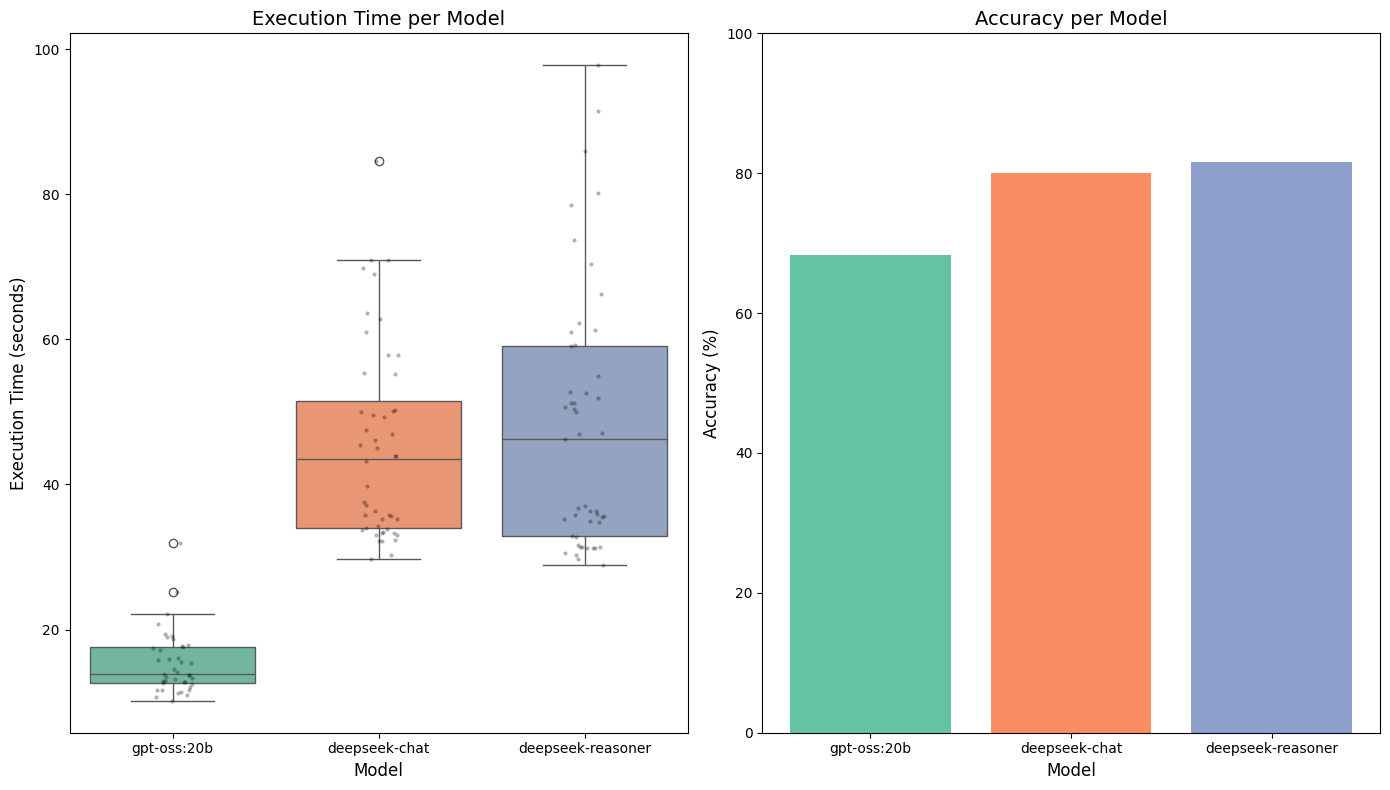

In [30]:
# Display stats table
display(stats_table)

# Execution time
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

ax1 = axes[0]
boxes = sns.boxplot(data=df_success, x='model', y='execution_time', hue="model", ax=ax1, palette='Set2')

ax1.set_title('Execution Time per Model', fontsize=14)
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('Execution Time (seconds)', fontsize=12)
# ax1.tick_params(axis='x', rotation=45)

# Add individual data points
sns.stripplot(data=df_success, x='model', y='execution_time', ax=ax1, color='black', alpha=0.3, size=3)

# Display bar diagram of accuracy (success rate) for each model
ax2 = axes[1]
accuracy_sorted = stats_table.sort_values('accuracy', ascending=True)
colors = sns.color_palette('Set2', len(accuracy_sorted))
bars = ax2.bar(accuracy_sorted['model'], accuracy_sorted['accuracy'], color=colors)

ax2.set_title('Accuracy per Model', fontsize=14)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylim(0,100)

plt.tight_layout()
plt.show()